In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv('../data/cleaned_data.csv', parse_dates=['Date'])

In [4]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Year,Month,Week,Quarter,log_sales,competition_flag,is_holiday,promo2_active,is_weekend,suspicious_store
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,2015,7,31,3,8.568646,0,1,0,0,0
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,2015,7,31,3,8.710290,1,1,1,0,0
2,3,4,2015-07-31,8314,821,1,1,0,1,a,...,2015,7,31,3,9.025816,0,1,1,0,0
3,4,4,2015-07-31,13995,1498,1,1,0,1,c,...,2015,7,31,3,9.546527,1,1,0,0,0
4,5,4,2015-07-31,4822,559,1,1,0,1,a,...,2015,7,31,3,8.481151,0,1,0,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 28 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  object        
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  str           
 10  Assortment                 844392 non-null  str           
 11  CompetitionDistance        844392 non-null  float64       
 12 

In [6]:
df.shape

(844392, 28)

In [7]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Week', 'Quarter',
       'log_sales', 'competition_flag', 'is_holiday', 'promo2_active',
       'is_weekend', 'suspicious_store'],
      dtype='str')

Building the store level profile dataframe

In [8]:
store_profile = df.groupby('Store').agg(
    avg_sales          = ('Sales', 'mean'),
    median_sales       = ('Sales', 'median'),
    std_sales          = ('Sales', 'std'),
    avg_customers      = ('Customers', 'mean'),
    promo_rate         = ('Promo', 'mean'),
    promo2_rate        = ('promo2_active', 'mean'),
    competition_dist   = ('CompetitionDistance', 'first'),
    competition_flag   = ('competition_flag', 'first'),
    holiday_rate       = ('is_holiday', 'mean'),
    store_type         = ('StoreType', 'first'),
    assortment         = ('Assortment', 'first'),
    avg_log_sales      = ('log_sales', 'mean'),
    sales_cv           = ('Sales', lambda x: x.std() / x.mean())         # sales_cv = coefficient of variation = how volatile this store's sales are
).reset_index()

In [9]:
store_profile.head()

,Store,avg_sales,median_sales,std_sales,avg_customers,promo_rate,promo2_rate,competition_dist,competition_flag,holiday_rate,store_type,assortment,avg_log_sales,sales_cv
0,1,4759.096031,4647.0,1012.106393,564.049936,0.448143,0.000000,1270.0,0,0.204866,c,a,8.446708,0.212668
1,2,4953.900510,4783.0,1610.149102,583.998724,0.451531,0.362245,570.0,1,0.197704,a,a,8.453979,0.325027
2,3,6942.568678,6619.0,2193.383804,750.077022,0.449294,0.364570,14130.0,0,0.200257,a,a,8.795941,0.315933
3,4,9638.401786,9430.5,1936.031881,1321.752551,0.450255,0.000000,620.0,1,0.202806,c,c,9.154714,0.200866
4,5,4676.274711,4616.0,1765.745628,537.340180,0.450578,0.000000,29910.0,0,0.204108,a,a,8.369616,0.377597


In [10]:
store_profile.isnull().sum()

Store               0
avg_sales           0
median_sales        0
std_sales           0
avg_customers       0
promo_rate          0
promo2_rate         0
competition_dist    0
competition_flag    0
holiday_rate        0
store_type          0
assortment          0
avg_log_sales       0
sales_cv            0
dtype: int64

Encoding the categorical variables so our model understands them better

In [11]:
print("StoreType values:", store_profile['store_type'].unique())
print("Assortment values:", store_profile['assortment'].unique())

StoreType values: <ArrowStringArray>
['c', 'a', 'd', 'b']
Length: 4, dtype: str
Assortment values: <ArrowStringArray>
['a', 'c', 'b']
Length: 3, dtype: str


Applying One Hot Encoding on both the columns

In [12]:
store_encoded = pd.get_dummies(
    store_profile,
    columns=['store_type', 'assortment'],
    prefix=['type', 'assort'],
    drop_first=False   
)

In [13]:
store_encoded.head()

,Store,avg_sales,median_sales,std_sales,avg_customers,promo_rate,promo2_rate,competition_dist,competition_flag,holiday_rate,avg_log_sales,sales_cv,type_a,type_b,type_c,type_d,assort_a,assort_b,assort_c
0,1,4759.096031,4647.0,1012.106393,564.049936,0.448143,0.000000,1270.0,0,0.204866,8.446708,0.212668,False,False,True,False,True,False,False
1,2,4953.900510,4783.0,1610.149102,583.998724,0.451531,0.362245,570.0,1,0.197704,8.453979,0.325027,True,False,False,False,True,False,False
2,3,6942.568678,6619.0,2193.383804,750.077022,0.449294,0.364570,14130.0,0,0.200257,8.795941,0.315933,True,False,False,False,True,False,False
3,4,9638.401786,9430.5,1936.031881,1321.752551,0.450255,0.000000,620.0,1,0.202806,9.154714,0.200866,False,False,True,False,False,False,True
4,5,4676.274711,4616.0,1765.745628,537.340180,0.450578,0.000000,29910.0,0,0.204108,8.369616,0.377597,True,False,False,False,True,False,False


In [14]:
store_encoded.shape

(1115, 19)

Applying scaling on below features:

In [15]:
cluster_features = [
    'avg_sales',                              # overall sales level
    'std_sales',                              # sales volatility
    'sales_cv',                               # relative volatility
    'promo_rate',                             # how often they promote
    'competition_dist',                       # competitive environment
    'type_a', 'type_b', 'type_c', 'type_d',   # store type
    'assort_a', 'assort_b', 'assort_c'        # assortment
]

Verify if all columns are present or not

In [16]:
missing = [c for c in cluster_features if c not in store_encoded.columns]
if missing:
    print("Missing columns:", missing)
else:
    print("All feature columns present")

All feature columns present


In [17]:
X = store_encoded[cluster_features].copy()

In [18]:
X.isnull().sum()

avg_sales           0
std_sales           0
sales_cv            0
promo_rate          0
competition_dist    0
type_a              0
type_b              0
type_c              0
type_d              0
assort_a            0
assort_b            0
assort_c            0
dtype: int64

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Calculating the mean and standard deviation of scaled features

In [20]:
print("Mean of scaled features:", X_scaled.mean(axis=0).round(3))

Mean of scaled features: [ 0. -0.  0. -0. -0.  0.  0. -0. -0.  0. -0.  0.]


In [21]:
print("Std of scaled features:", X_scaled.std(axis=0).round(3))

Std of scaled features: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Finding the optimal k-value for k-means clustering

In [22]:
inertia_values = []
silhouette_values = []
k_range = range(2, 10)

In [23]:
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))
    print(f"k={k}  |  Inertia: {km.inertia_:,.0f}  " f"|  Silhouette: {silhouette_score(X_scaled, labels):.4f}")

k=2  |  Inertia: 11,008  |  Silhouette: 0.2558
k=3  |  Inertia: 8,555  |  Silhouette: 0.2728
k=4  |  Inertia: 7,465  |  Silhouette: 0.3032
k=5  |  Inertia: 6,242  |  Silhouette: 0.3515
k=6  |  Inertia: 5,576  |  Silhouette: 0.3836
k=7  |  Inertia: 4,893  |  Silhouette: 0.3799
k=8  |  Inertia: 4,326  |  Silhouette: 0.3847
k=9  |  Inertia: 3,807  |  Silhouette: 0.3998


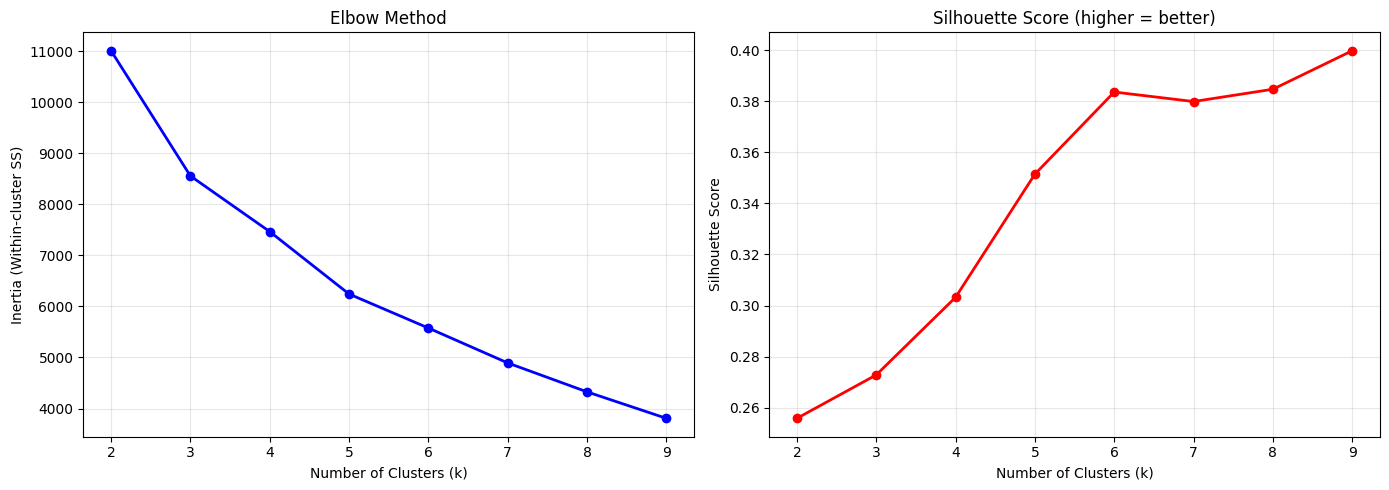

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia_values, 'bo-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster SS)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)


axes[1].plot(list(k_range), silhouette_values, 'ro-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score (higher = better)')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

Fit the final k means model

In [25]:
OPTIMAL_K = 4

kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
store_encoded['cluster'] = kmeans_final.fit_predict(X_scaled)
store_profile['cluster'] = store_encoded['cluster'].values

print("Cluster distribution:")
print(store_profile['cluster'].value_counts().sort_index())

store_profile.to_csv('../store_profiles_clustered.csv', index=False)

Cluster distribution:
cluster
0    292
1    348
2     17
3    458
Name: count, dtype: int64


In [26]:
small_cluster = store_profile[
    store_profile['cluster'] == 2  # whichever has 17 stores
]
print(small_cluster['store_type'].value_counts())
print(small_cluster['avg_sales'].describe())

store_type
b    17
Name: count, dtype: int64
count       17.000000
mean     10110.779605
std       4593.997196
min       4070.828326
25%       6936.760776
50%       9744.599788
75%      11643.638412
max      20718.515924
Name: avg_sales, dtype: float64


Visualizing clusters with PCA

In [27]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [28]:
pca_df = pd.DataFrame({
    'PC1':    X_pca[:, 0],
    'PC2':    X_pca[:, 1],
    'Cluster': store_profile['cluster'].astype(str),
    'Store':   store_profile['Store'],
    'AvgSales': store_profile['avg_sales'].round(0)
})

In [29]:
fig = px.scatter(pca_df,
                 x='PC1', y='PC2',
                 color='Cluster',
                 hover_data=['Store', 'AvgSales'],
                 title=f'Store Clusters (PCA 2D projection, k={OPTIMAL_K})',
                 labels={'PC1': f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
                         'PC2': f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)'})


fig.show()

The first two principal components explain ~40.6% of the total variance.

This indicates that store behavior differences exist across multiple dimensions beyond what can be fully represented in 2D space.
Importantly, KMeans clustering was performed in the original scaled feature space, not on the PCA projection itself.

In [30]:
cluster_summary = store_profile.groupby('cluster').agg(
    num_stores       = ('Store', 'count'),
    avg_sales        = ('avg_sales', 'mean'),
    avg_customers    = ('avg_customers', 'mean'),
    promo_rate       = ('promo_rate', 'mean'),
    competition_dist = ('competition_dist', 'mean'),
    sales_volatility = ('sales_cv', 'mean')
).round(2).reset_index()

cluster_summary

,cluster,num_stores,avg_sales,avg_customers,promo_rate,competition_dist,sales_volatility
0,0,292,7439.75,837.74,0.45,7004.25,0.27
1,1,348,6823.74,604.21,0.45,8022.76,0.26
2,2,17,10110.78,1998.68,0.38,1060.59,0.25
3,3,458,6577.92,769.47,0.45,3832.01,0.28


In [31]:
for c in range(OPTIMAL_K):
    cluster_stores = store_profile[store_profile['cluster'] == c]
    dominant_type  = cluster_stores['store_type'].value_counts().index[0]
    dominant_assort = cluster_stores['assortment'].value_counts().index[0]
    print(f"\nCluster {c}: "
          f"n={len(cluster_stores)}, "
          f"dominant_type={dominant_type}, "
          f"assortment={dominant_assort}")


Cluster 0: n=292, dominant_type=a, assortment=c

Cluster 1: n=348, dominant_type=d, assortment=c

Cluster 2: n=17, dominant_type=b, assortment=b

Cluster 3: n=458, dominant_type=a, assortment=a


Merging cluster labels back into main dataframe so that we can know which cluster does this store belong to


In [32]:
cluster_map = store_profile.set_index('Store')['cluster'].to_dict()
df['cluster'] = df['Store'].map(cluster_map)

In [33]:
print("Unmapped stores:", df['cluster'].isnull().sum())

Unmapped stores: 0


In [34]:
df.to_csv('../cleaned_data.csv', index=False)

In [35]:
print(df['cluster'].value_counts().sort_index())

cluster
0    225441
1    258774
2     15563
3    344614
Name: count, dtype: int64


In [36]:
# Check what columns you have
print(df.columns.tolist())
print("cluster" in df.columns)

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Week', 'Quarter', 'log_sales', 'competition_flag', 'is_holiday', 'promo2_active', 'is_weekend', 'suspicious_store', 'cluster']
True


In [37]:
print("cluster" in df.columns)
df.to_csv('../data/cleaned_data.csv', index=False)
print("Done. Columns:", df.columns.tolist())

True
Done. Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Week', 'Quarter', 'log_sales', 'competition_flag', 'is_holiday', 'promo2_active', 'is_weekend', 'suspicious_store', 'cluster']


In [38]:
# Check which columns you actually use in the dashboard
keep_cols = [
    'Store', 'Date', 'Sales', 'Promo', 'StoreType',
    'Assortment', 'CompetitionDistance', 'DayOfWeek',
    'Month', 'Year', 'Week', 'StateHoliday', 'SchoolHoliday',
    'is_holiday', 'log_sales', 'competition_flag',
    'promo2_active', 'cluster', 'cluster_name'
]

# Only keep columns that exist
keep_cols = [c for c in keep_cols if c in df.columns]
df_small  = df[keep_cols].copy()

print(f"Original shape: {df.shape}")
print(f"Reduced shape:  {df_small.shape}")

df_small.to_csv('../data/cleaned_data.csv', index=False)

# Check new size
import os
size = os.path.getsize('../data/cleaned_data.csv') / 1e6
print(f"New file size: {size:.1f} MB")

Original shape: (844392, 29)
Reduced shape:  (844392, 18)
New file size: 64.0 MB
